# P3 - Elbow + K-means Validation of Saved CNN Features

This independent notebook reads the outputs of P2 CNN Feature Extraction. It does not import PyTorch, load weights, crop images or execute the CNN. Both original and orientation-averaged representations are evaluated.

The final cluster number is selected by the same endpoint-chord Elbow heuristic used in the previous combined notebook, not fixed to five. "Validation" here means internal diagnostics and output consistency, not verified molecular accuracy.


## 1. Read saved features and verify their provenance

No P2 notebook needs to remain open. Run P2 once before this notebook; rerunning P2 is only necessary if extraction inputs/settings change.


In [1]:
from pathlib import Path
import hashlib
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from threadpoolctl import threadpool_limits

%matplotlib inline

SEED = 42
PCA_VARIANCE = 0.95
K_MAX = 10

def locate_package(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start,*start.parents):
        if (candidate/"Project_Data").is_dir() and (candidate/"Notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Start Jupyter inside the extracted share package.")

def sha256(path):
    h = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda:stream.read(1024*1024),b""):
            h.update(block)
    return h.hexdigest()

ROOT = locate_package()
FEATURE_DIR = ROOT/"Notebooks/P2/outputs/alternative1_cnn_features"
P1_DIR = ROOT/"Notebooks/P1/outputs/alternative_1_plane_fitting"
OUT = ROOT/"Notebooks/P3/outputs/cnn_elbow_kmeans"
OUT.mkdir(parents=True,exist_ok=True)

def relative(path):
    return path.relative_to(ROOT).as_posix()

manifest_path = FEATURE_DIR/"feature_manifest.json"
if not manifest_path.is_file():
    raise FileNotFoundError("Run the P2 CNN Feature Extraction notebook first.")
feature_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
assert feature_manifest["schema_version"] == 1
assert feature_manifest["stage"] == "cnn_feature_extraction_only"
feature_artifacts = [
    "original_cnn_features.npy","orientation_average_cnn_features.npy",
    "patch_index.csv","candidate_metadata.csv","patches_gray.npy",
    "patches_height_m.npy","patch_masks.npy",
]
feature_hashes = {}
for name in feature_artifacts:
    path = FEATURE_DIR/name
    if not path.is_file():
        raise FileNotFoundError(f"Missing P2 artifact: {name}")
    feature_hashes[name] = sha256(path)
    if feature_hashes[name] != feature_manifest["artifact_hashes"][name]:
        raise ValueError(f"P2 artifact checksum mismatch: {name}. Rerun P2.")
for name,digest in feature_manifest["input_hashes"].items():
    path = P1_DIR/name
    if not path.is_file() or sha256(path)!=digest:
        raise ValueError(f"P1 changed after feature extraction: {name}. Rerun P2.")
manifest_hash = sha256(manifest_path)
patch_index = pd.read_csv(FEATURE_DIR/"patch_index.csv")
objects = pd.read_csv(FEATURE_DIR/"candidate_metadata.csv")
ids = patch_index.object_id.to_numpy(dtype=int)
assert patch_index.object_id.is_unique and objects.object_id.is_unique
assert np.array_equal(ids,objects.object_id.to_numpy())
assert len(ids)==feature_manifest["candidate_count"]
if len(ids)<4:
    raise ValueError("At least four candidates are required for these validation experiments.")
height = np.load(P1_DIR/"corrected_height.npy")
labels = np.load(P1_DIR/"label_image.npy")
patches = np.load(FEATURE_DIR/"patches_gray.npy")
assert height.shape == labels.shape and np.isfinite(height).all()
assert np.array_equal(ids,np.unique(labels[labels>0]))
assert patches.shape[0]==len(ids)
feature_sets = {name:np.load(FEATURE_DIR/f"{name}_cnn_features.npy")
                for name in ["original","orientation_average"]}
for features in feature_sets.values():
    assert features.shape==(len(ids),512) and np.isfinite(features).all()
print("Read-only CNN input:",relative(FEATURE_DIR))
print("Validation output:",relative(OUT))
print("Candidates:",len(ids))

from sklearn.cluster import KMeans
N_INIT = 50
METHOD_LABEL = "CNN + Elbow + K-means"
METHOD_CONFIGURATION = {"n_init":N_INIT,"k_selection":"normalised endpoint-chord elbow"}


Read-only CNN input: Notebooks/P2/outputs/alternative1_cnn_features
Validation output: Notebooks/P3/outputs/cnn_elbow_kmeans
Candidates: 248


## 2. Identical feature preparation for the two validation methods

Remove constant dimensions, apply StandardScaler, then PCA retaining at least 95% of variance using full SVD without whitening. This source cell is identical in both validation notebooks. Each representation has its own fitted transformation, but both algorithms receive the same transformed matrix for that representation.

This is exploratory analysis of the current scan, not a held-out accuracy test. PCA is fitted here, not in the CNN extractor. Comparing BIC across different representations or different PCA dimensions is not valid; compare it only among models fitted to the same matrix.


In [2]:
representations, transforms, preparation_rows = {}, {}, []
for name,features in feature_sets.items():
    keep = np.std(features,axis=0)>1e-12
    if keep.sum()<1:
        raise ValueError(f"No nonconstant features: {name}")
    scaler = StandardScaler()
    standardised = scaler.fit_transform(features[:,keep])
    pca = PCA(n_components=PCA_VARIANCE,svd_solver="full",whiten=False)
    matrix = pca.fit_transform(standardised)
    assert np.isfinite(matrix).all()
    representations[name] = matrix
    transforms[name] = {
        "retained_columns":np.flatnonzero(keep),
        "scaler_mean":scaler.mean_,"scaler_scale":scaler.scale_,
        "pca_mean":pca.mean_,"pca_components":pca.components_,
        "explained_variance_ratio":pca.explained_variance_ratio_,
    }
    np.save(OUT/f"{name}_pca_features.npy",matrix)
    preparation_rows.append({"representation":name,"retained_cnn_dimensions":int(keep.sum()),
                             "pca_dimensions":matrix.shape[1],
                             "retained_variance":float(pca.explained_variance_ratio_.sum())})
preparation = pd.DataFrame(preparation_rows)
preparation.to_csv(OUT/"feature_preparation.csv",index=False)
display(preparation)


,representation,retained_cnn_dimensions,pca_dimensions,retained_variance
0,original,512,39,0.950535
1,orientation_average,512,15,0.953332


## 3. Select k and fit K-means

Search k=1..10 on the same PCA matrix used by the final fit. The normalised curve's farthest interior point from the endpoint chord is the selected elbow. A flat curve raises an error rather than forcing a group number. This heuristic can favour coarse structure and is not a chemical class-count estimator.

Cluster IDs are ordered by mean area for readability. Area is used only for renumbering after fitting. Counts and silhouettes describe the partition, not correctness.


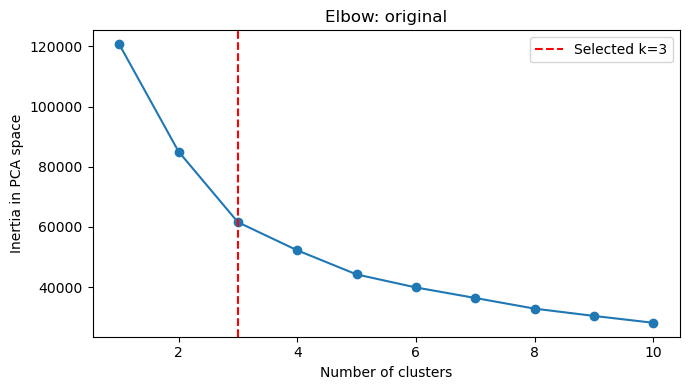

,cluster_id,cluster_label,candidate_count
0,1,C1,99
1,2,C2,115
2,3,C3,34


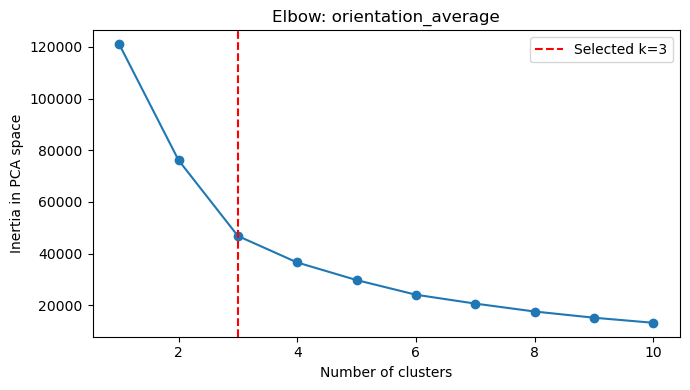

,cluster_id,cluster_label,candidate_count
0,1,C1,99
1,2,C2,118
2,3,C3,31


,representation,candidate_count,retained_cnn_dimensions,pca_dimensions,retained_variance,selected_k,silhouette
0,original,248,512,39,0.950535,3,0.363075
1,orientation_average,248,512,15,0.953332,3,0.490215


In [3]:
def select_elbow(ks, inertias):
    ks, values = np.asarray(ks, dtype=float), np.asarray(inertias, dtype=float)
    if len(ks) < 3 or not np.isfinite(values).all() or np.ptp(values) <= 0:
        raise ValueError("Insufficient non-flat data for an elbow.")
    if np.any(np.diff(values) > 1e-7 * max(1.0, values[0])):
        raise ValueError("Inertia increased; inspect convergence before selecting k.")
    x = (ks - ks.min()) / np.ptp(ks)
    y = (values - values.min()) / np.ptp(values)
    distance = np.abs(x + y - 1) / np.sqrt(2)
    distance[[0, -1]] = -np.inf
    if np.max(distance) <= 1e-10:
        raise ValueError("No distinct elbow. Inspect the curve rather than forcing a class count.")
    return int(ks[np.argmax(distance)]), distance

assert select_elbow([1,2,3,4,5], [100,45,20,18,17])[0] == 3
try:
    select_elbow([1,2,3], [10,10,10])
except ValueError:
    pass
else:
    raise AssertionError("A flat curve must not produce an elbow.")

results, metrics_rows = {}, []
for name, matrix in representations.items():
    max_k = min(K_MAX, len(ids)-1, len(np.unique(matrix, axis=0)))
    ks = np.arange(1, max_k+1)
    inertias = []
    with threadpool_limits(limits=1):
        for k in ks:
            trial = KMeans(n_clusters=int(k), n_init=N_INIT, random_state=SEED).fit(matrix)
            inertias.append(float(trial.inertia_))
        selected, distances = select_elbow(ks, inertias)
        fitted = KMeans(n_clusters=selected, n_init=N_INIT, random_state=SEED).fit(matrix)
    assert np.isclose(fitted.inertia_, inertias[list(ks).index(selected)])
    if len(np.unique(fitted.labels_)) != selected:
        raise ValueError("Fewer distinct clusters than requested; inspect duplicated features.")
    # Renumber by mean physical area for readable within-image IDs only.
    order = sorted(range(selected), key=lambda c: objects.loc[fitted.labels_==c, "area_nm2"].mean())
    mapping = {raw: i+1 for i, raw in enumerate(order)}
    groups = np.array([mapping[int(c)] for c in fitted.labels_])
    assignments = objects[["object_id", "centroid_row", "centroid_col"]].copy()
    assignments["cluster_id"] = groups
    assignments["cluster_label"] = [f"C{g}" for g in groups]
    counts = assignments.groupby(["cluster_id","cluster_label"]).size().reset_index(name="candidate_count")
    score = float(silhouette_score(matrix, fitted.labels_))
    search = pd.DataFrame({"k":ks, "inertia":inertias, "chord_distance":distances,
                           "selected":ks==selected})
    search["chord_distance"] = search["chord_distance"].replace([-np.inf,np.inf], np.nan)
    results[name] = {"k":selected, "groups":groups, "assignments":assignments, "counts":counts}
    assignments.to_csv(OUT/f"{name}_assignments.csv", index=False)
    counts.to_csv(OUT/f"{name}_counts.csv", index=False)
    search.to_csv(OUT/f"{name}_elbow.csv", index=False)
    np.save(OUT/f"{name}_pca_features.npy", matrix)
    np.savez_compressed(OUT/f"{name}_transform.npz",**transforms[name],
        kmeans_centres=fitted.cluster_centers_,
        raw_to_group=np.array([mapping[c] for c in range(selected)]))
    metrics_rows.append({"representation":name,"candidate_count":len(ids),"retained_cnn_dimensions":len(transforms[name]["retained_columns"]),
                         "pca_dimensions":matrix.shape[1],"retained_variance":float(transforms[name]["explained_variance_ratio"].sum()),
                         "selected_k":selected,"silhouette":score})
    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(ks,inertias,"o-")
    ax.axvline(selected,color="red",linestyle="--",label=f"Selected k={selected}")
    ax.set(xlabel="Number of clusters",ylabel="Inertia in PCA space",title=f"Elbow: {name}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT/f"{name}_elbow.png",dpi=160)
    plt.show()
    display(counts)

metrics = pd.DataFrame(metrics_rows)
metrics.to_csv(OUT/"representation_comparison.csv",index=False)
display(metrics)


## 4. Show grouping on the original image and representative patches

Colours refer to candidate groups within one representation only. C1 in one branch is not guaranteed to match C1 in the other branch or another scan. Background and any P1-excluded objects remain uncoloured.

The first two PCA coordinates are only a visual projection. Clustering uses all retained components, not just the two displayed axes. The montage shows candidates nearest each fitted centre, not manually selected success examples.


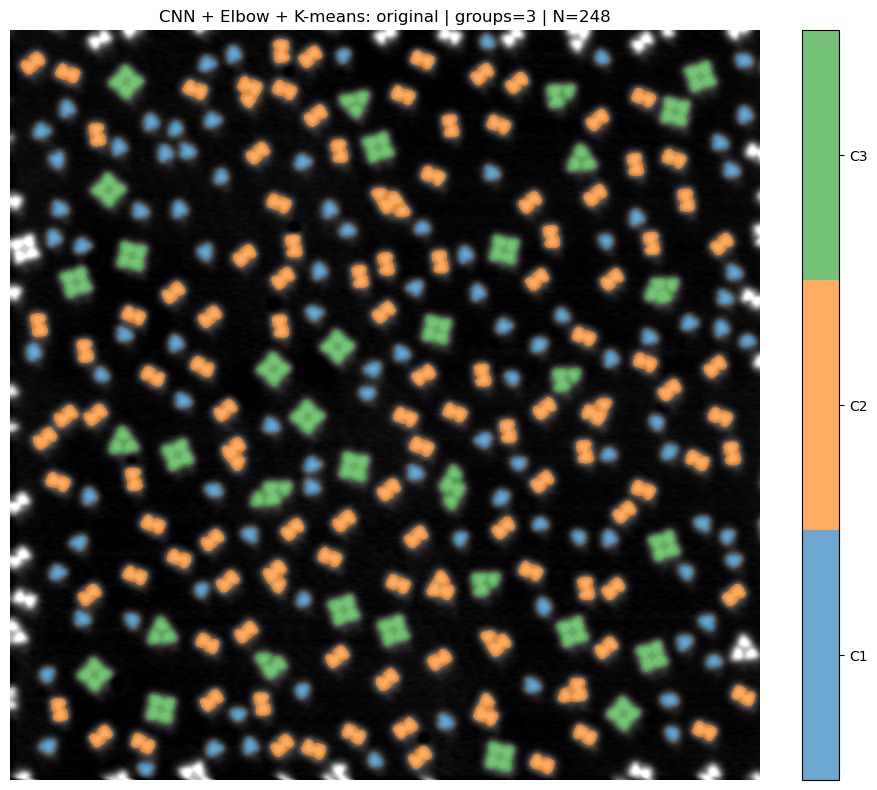

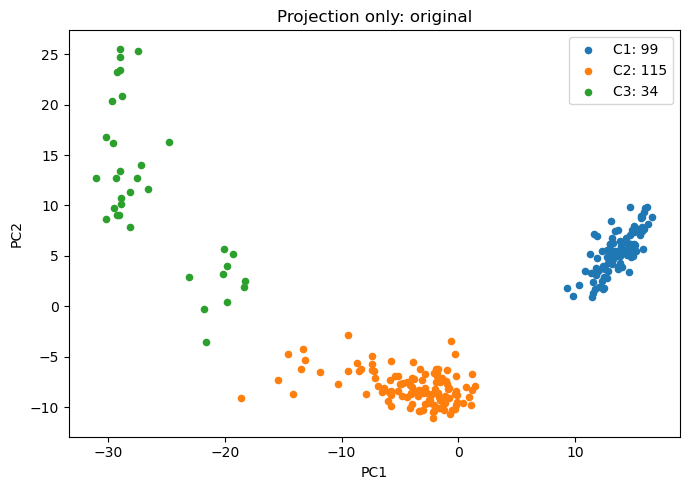

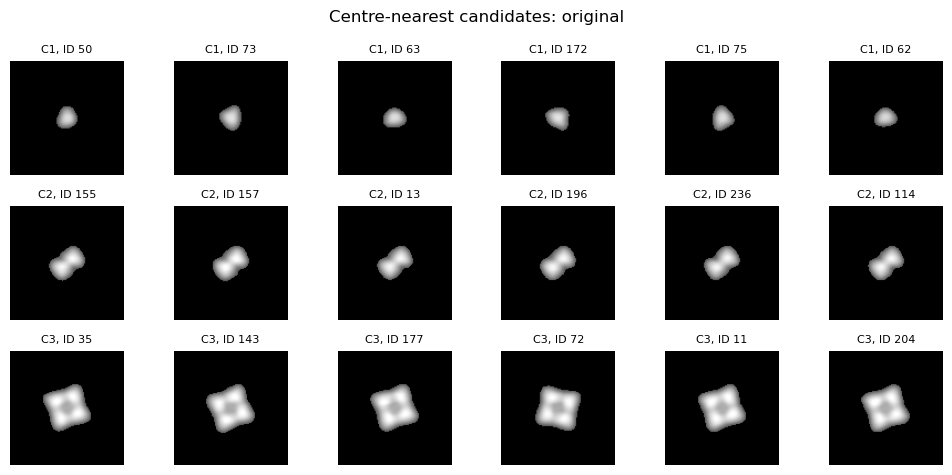

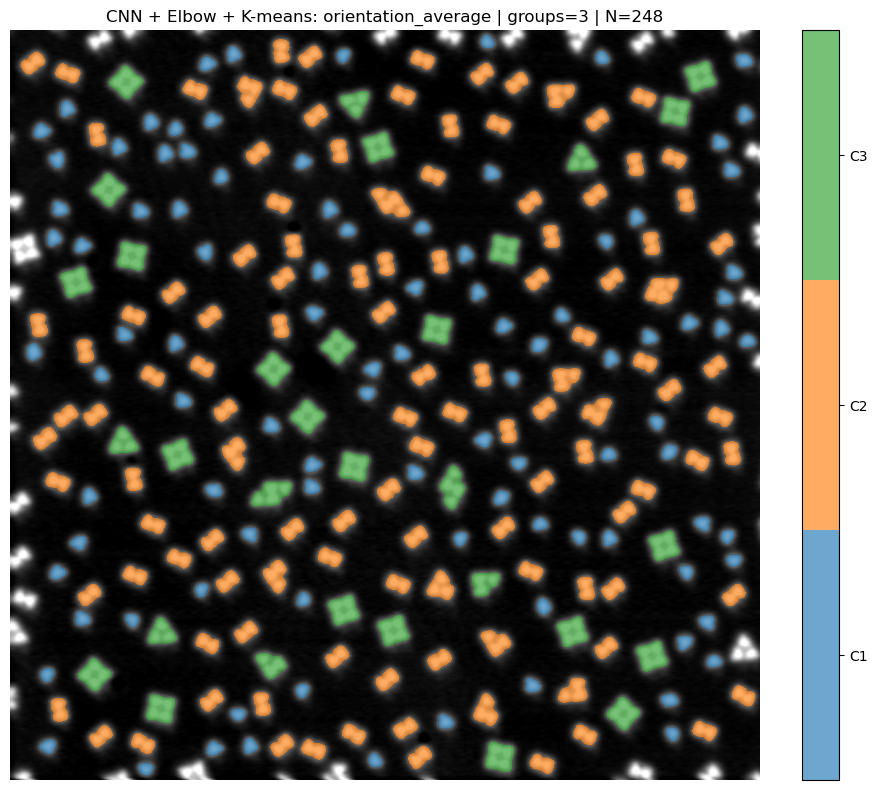

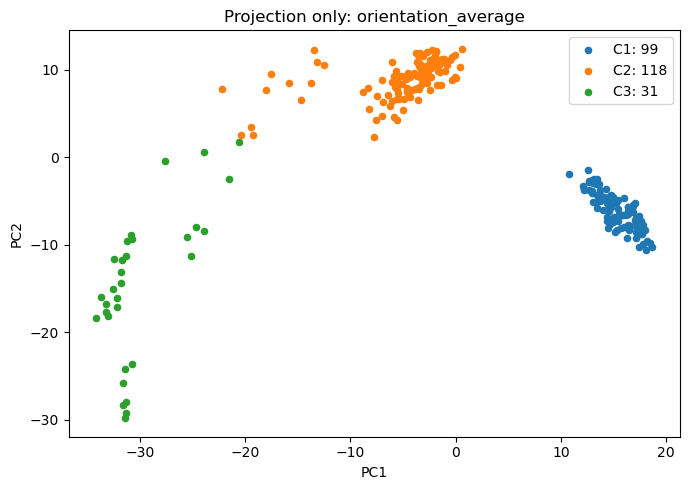

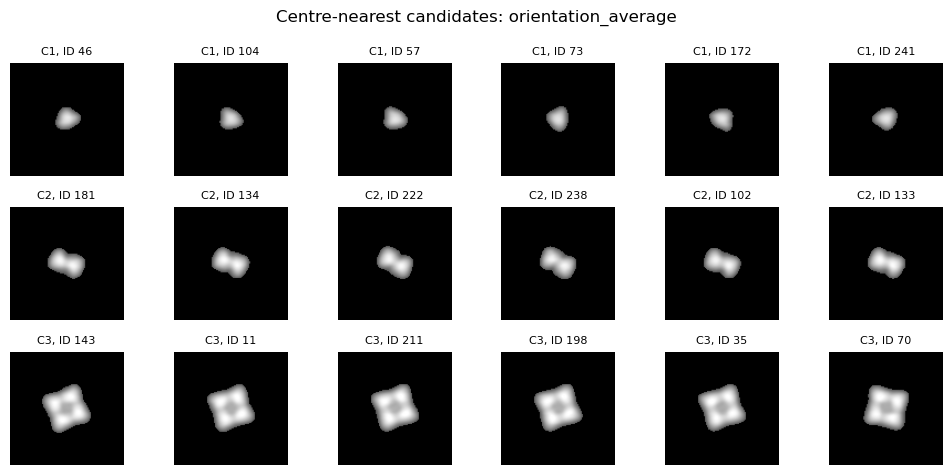

In [4]:
for name, result in results.items():
    k, groups = result["k"], result["groups"]
    colours = list(plt.colormaps["tab10"].colors[:k])
    lookup = np.zeros(int(labels.max())+1, dtype=np.int16)
    lookup[ids] = groups
    group_image = lookup[labels]
    assert np.array_equal(group_image>0, labels>0)
    np.save(OUT/f"{name}_cluster_image.npy", group_image)
    fig, ax = plt.subplots(figsize=(9,8))
    low_display, high_display = np.percentile(height,[2,98])
    ax.imshow(height,cmap="gray",vmin=low_display,vmax=high_display)
    overlay = ax.imshow(np.ma.masked_where(group_image==0,group_image),
                        cmap=ListedColormap(colours),vmin=0.5,vmax=k+0.5,alpha=0.65)
    cb = fig.colorbar(overlay,ax=ax,ticks=np.arange(1,k+1),fraction=0.045)
    cb.ax.set_yticklabels([f"C{i}" for i in range(1,k+1)])
    ax.set_title(f"{METHOD_LABEL}: {name} | groups={k} | N={len(ids)}")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(OUT/f"{name}_classification_overlay.png",dpi=160,bbox_inches="tight")
    plt.show()
    matrix = representations[name]
    fig, ax = plt.subplots(figsize=(7,5))
    for group, colour in enumerate(colours,1):
        mask = groups==group
        ax.scatter(matrix[mask,0],matrix[mask,1] if matrix.shape[1]>1 else np.zeros(mask.sum()),
                   color=colour,s=20,label=f"C{group}: {mask.sum()}")
    ax.set(xlabel="PC1",ylabel="PC2",title=f"Projection only: {name}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT/f"{name}_pca_scatter.png",dpi=160)
    plt.show()
    fig, axes = plt.subplots(k,6,figsize=(10,1.6*k),squeeze=False)
    for group in range(1,k+1):
        members = np.flatnonzero(groups==group)
        centre = matrix[members].mean(axis=0)
        selected = members[np.argsort(np.linalg.norm(matrix[members]-centre,axis=1))[:6]]
        for j, ax in enumerate(axes[group-1]):
            ax.axis("off")
            if j<len(selected):
                i=selected[j]
                ax.imshow(patches[i],cmap="gray",vmin=0,vmax=1)
                ax.set_title(f"C{group}, ID {ids[i]}",fontsize=8)
    fig.suptitle(f"Centre-nearest candidates: {name}")
    fig.tight_layout()
    fig.savefig(OUT/f"{name}_representatives.png",dpi=150,bbox_inches="tight")
    plt.show()


## 5. Check exports and read-only inputs

Confirm all candidates are assigned once and P1/P2 artifacts were not modified. Export this method's results only into its own P3 output folder.


In [5]:
assert {name:sha256(FEATURE_DIR/name) for name in feature_artifacts}==feature_hashes
assert sha256(manifest_path)==manifest_hash
assert all(sha256(P1_DIR/name)==digest for name,digest in feature_manifest["input_hashes"].items())
for name,result in results.items():
    saved = pd.read_csv(OUT/f"{name}_assignments.csv")
    saved_counts = pd.read_csv(OUT/f"{name}_counts.csv")
    assert np.array_equal(saved.object_id.to_numpy(),ids) and saved.object_id.is_unique
    assert saved_counts.candidate_count.sum()==len(ids)
    assert saved.cluster_id.nunique()==result["k"]
    for suffix in ["classification_overlay.png","pca_scatter.png","representatives.png"]:
        assert (OUT/f"{name}_{suffix}").stat().st_size>0
run_manifest = {
    "method":METHOD_LABEL,"feature_directory":relative(FEATURE_DIR),
    "output_directory":relative(OUT),"cnn_manifest_sha256":manifest_hash,
    "feature_hashes":feature_hashes,"candidate_count":len(ids),
    "molecular_labels_used":False,"cnn_executed":False,
    "pca_variance":PCA_VARIANCE,"k_search_max":K_MAX,"seed":SEED,
    "method_configuration":METHOD_CONFIGURATION,
    "results":json.loads(metrics.to_json(orient="records")),
}
(OUT/"run_manifest.json").write_text(json.dumps(run_manifest,indent=2,allow_nan=False),encoding="utf-8")
print("Validation outputs saved:",relative(OUT))
print("P1 and P2 inputs unchanged. No CNN execution was needed.")
display(metrics)


Validation outputs saved: Notebooks/P3/outputs/cnn_elbow_kmeans
P1 and P2 inputs unchanged. No CNN execution was needed.


,representation,candidate_count,retained_cnn_dimensions,pca_dimensions,retained_variance,selected_k,silhouette
0,original,248,512,39,0.950535,3,0.363075
1,orientation_average,248,512,15,0.953332,3,0.490215
